# Unit Tests for _mutate_safe_fragment

This notebook tests the `_mutate_safe_fragment` method from DAPSSampler with various molecules and visualizes the mutations before and after.

In [105]:
import sys
import os
import unittest
import random
import warnings

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
import torch

# Suppress warnings
warnings.filterwarnings('ignore')

# Add genmol to path
sys.path.insert(0, '/disk1/jyang4/repos/genmol/src')

print("Libraries imported successfully!")

Libraries imported successfully!


## Section 1: Import RDKit and Visualization Tools

In [106]:
from rdkit import Chem
from rdkit.Chem import AllChem, Draw, Descriptors

print("RDKit imported successfully!")

RDKit imported successfully!


## Section 2: Load DAPSSampler and Initialize

In [112]:
import safe as sf
import datamol as dm
import re
from typing import List, Set, Tuple, Optional, Dict

class SafeFragmentLinker:
    """
    Handles SAFE string fragment linking/unlinking operations.
    Works directly in SAFE space with explicit attachment points.
    Ensures fragments are attachment-compatible when adding or swapping.
    Generates novel fragments using fragment_completion (inspired by genmol's generate/attach).
    """
    
    def __init__(self, seed=42, sampler=None):
        """
        Initialize the linker.
        
        Args:
            seed: Random seed for reproducibility
            sampler: Optional Sampler object for generating novel fragments
                    If provided, add/swap will generate new fragments instead of selecting from pool
        """
        self.converter = sf.SAFEConverter()
        self.sampler = sampler
        self.rng = np.random.RandomState(seed)
        random.seed(seed)
    
    def encode_smiles_to_safe(self, smiles: str) -> str:
        """Convert SMILES to SAFE representation."""
        try:
            safe_str = self.converter.encoder(smiles)
            return safe_str if safe_str else None
        except:
            return None
    
    def decode_safe_to_smiles(self, safe_str: str) -> str:
        """Convert SAFE back to SMILES."""
        try:
            smiles = self.converter.decoder(safe_str)
            return smiles if smiles else None
        except:
            return None
    
    def split_safe_fragments(self, safe_str: str) -> List[str]:
        """Split SAFE string by dots to get individual fragments."""
        if not safe_str:
            return []
        fragments = [f.strip() for f in safe_str.split('.') if f.strip()]
        return fragments
    
    def join_safe_fragments(self, fragments: List[str]) -> str:
        """Join fragments with dots."""
        return '.'.join(f for f in fragments if f)
    
    def get_attachment_points(self, safe_str: str) -> List[int]:
        """Extract all attachment point numbers from SAFE string."""
        import re
        # Find all numbers in the SAFE string
        numbers = re.findall(r'\d+', safe_str)
        return sorted(set(int(n) for n in numbers))
    
    def _build_fragment_graph(self, fragments: List[str]) -> List[Set[int]]:
        """Build fragment adjacency based on shared attachment point numbers."""
        ap_to_frags: Dict[int, List[int]] = {}
        for idx, frag in enumerate(fragments):
            for ap in self.get_attachment_points(frag):
                ap_to_frags.setdefault(ap, []).append(idx)
        
        adj = [set() for _ in fragments]
        for frags in ap_to_frags.values():
            if len(frags) < 2:
                continue
            for i in range(len(frags)):
                for j in range(i + 1, len(frags)):
                    a, b = frags[i], frags[j]
                    adj[a].add(b)
                    adj[b].add(a)
        
        return adj
    
    def _is_connected(self, fragments: List[str]) -> bool:
        """Check if fragments form a single connected component via attachment points."""
        if len(fragments) <= 1:
            return True
        adj = self._build_fragment_graph(fragments)
        
        # If there are no edges, it's disconnected
        if all(len(neigh) == 0 for neigh in adj):
            return False
        
        visited = set()
        stack = [0]
        while stack:
            node = stack.pop()
            if node in visited:
                continue
            visited.add(node)
            for nbr in adj[node]:
                if nbr not in visited:
                    stack.append(nbr)
        
        return len(visited) == len(fragments)
    
    def generate_novel_fragment(self, template_fragment: str = None) -> str:
        """
        Generate a novel fragment using the sampler (inspired by genmol's generate/attach pattern).
        
        If sampler is available:
          - Use fragment_completion to generate new molecules around a template
          - Extract a fragment from the generated molecule
        If no sampler available:
          - Generate a random small SAFE fragment
        
        Args:
            template_fragment: Optional template fragment to condition generation on
        
        Returns:
            A novel SAFE fragment string
        """
        if self.sampler is not None:
            try:
                # Use fragment_completion to generate novel molecules
                # This mimics how genmol's attach() generates new fragments
                if template_fragment:
                    # Generate completions around the template
                    samples = self.sampler.fragment_completion(
                        template_fragment, 
                        num_samples=1,
                        apply_filter=True
                    )
                else:
                    # Generate de novo molecules
                    samples = self.sampler.de_novo_generation(num_samples=1)
                
                if samples and samples[0]:
                    # Convert generated SMILES to SAFE and extract first fragment
                    safe_str = self.encode_smiles_to_safe(samples[0])
                    if safe_str:
                        frags = self.split_safe_fragments(safe_str)
                        if frags:
                            # Return the first fragment
                            return frags[0]
            except Exception as e:
                # Fall through to random generation
                pass
        
        # Fallback: generate random small aromatic fragment with attachment points
        # This ensures we get novel fragments, not from the original pool
        aromatic_cores = [
            "c1ccccc1",      # benzene
            "c1ccncc1",      # pyridine
            "c1cccnc1",      # pyridine isomer
            "c1ccsc1",       # thiophene
            "c1ccoc1",       # furan
            "c1ccc2ccccc2c1", # naphthalene (with AP)
        ]
        
        # Add attachment points randomly
        core = random.choice(aromatic_cores)
        # Add attachment point numbers
        frag_with_ap = core + str(random.randint(1, 3))
        return frag_with_ap
    
    def identify_extension_points(self, smiles: str) -> List[Dict]:
        """
        Identify extension points in a molecule where new fragments can be added.
        Extension points are positions with available valence for bonding.
        
        This is the first step in SAFE motif extension: finding where to extend.
        
        Args:
            smiles: SMILES string of the motif/molecule
            
        Returns:
            List of dicts with keys:
                - 'atom_idx': index of atom
                - 'atom_symbol': atomic symbol
                - 'available_valence': number of available bonds
                - 'with_dummy': SMILES with dummy atom added at this position
        """
        try:
            mol = Chem.MolFromSmiles(smiles)
            if mol is None:
                return []
            
            extension_points = []
            pt = Chem.GetPeriodicTable()
            
            for atom in mol.GetAtoms():
                explicit_val = atom.GetExplicitValence()
                implicit_val = atom.GetImplicitValence()
                total_val = explicit_val + implicit_val
                
                # Get allowed valences for this element
                allowed_valences = pt.GetValenceList(atom.GetAtomicNum())
                max_val = max(allowed_valences) if allowed_valences else 4
                
                # If we can add more bonds, this is an extension point
                available_bonds = max_val - total_val
                if available_bonds > 0:
                    # Create a version with dummy atom at this position
                    emol = Chem.EditableMol(mol)
                    dummy_idx = emol.AddAtom(Chem.Atom(0))  # Dummy atom with atomic num 0
                    emol.AddBond(atom.GetIdx(), dummy_idx, Chem.BondType.SINGLE)
                    mol_with_dummy = emol.GetMol()
                    smiles_with_dummy = Chem.MolToSmiles(mol_with_dummy)
                    
                    extension_points.append({
                        'atom_idx': atom.GetIdx(),
                        'atom_symbol': atom.GetSymbol(),
                        'available_valence': available_bonds,
                        'with_dummy': smiles_with_dummy
                    })
            
            return extension_points
        except Exception as e:
            return []
    
    def add_with_motif_extension(self, motif_smiles: str, n_candidates: int = 5) -> str:
        """
        Perform motif extension using SAFEDesign.motif_extension() API.
        
        This follows the SAFE protocol from https://github.com/datamol-io/safe:
        1. Open attachment points on the motif using SAFE utilities
        2. Use SAFEDesign.motif_extension() to generate candidate molecules  
        3. Filter results and select the best one
        
        The motif_extension task is implemented as scaffold decoration in SAFE,
        where the model generates diverse extensions from the motif structure.
        
        Args:
            motif_smiles: SMILES string of the motif to extend
            n_candidates: Number of candidate molecules to generate (default 5)
            
        Returns:
            SMILES string of best extended molecule, or None if extension fails
        """
        try:
            mol = dm.to_mol(motif_smiles)
            if mol is None:
                return None
            
            # Step 1: Open up attachment points using SAFE utilities
            # This gets molecules with [*] attachment points at various positions
            from safe import utils
            motifs_with_aps = list(utils.list_individual_attach_points(mol))
            
            if not motifs_with_aps:
                return None
            
            # Select a random motif with attachment point
            motif_with_ap = random.choice(motifs_with_aps)
            
            # Step 2: Use SAFEDesign.motif_extension() to generate candidates
            try:
                designer = sf.SAFEDesign.load_default(verbose=False)
                current_length = len(motif_with_ap)
                # motif_extension is a wrapper around scaffold_decoration
                # It takes the motif with attachment points and generates extensions
                candidates = designer.motif_extension(
                    motif=motif_with_ap,
                    n_samples_per_trial=n_candidates,
                    n_trials=1,
                    sanitize=True,
                    do_not_fragment_further=True,
                    random_seed=42,
                    # min_length=current_length + 1,
                    # max_length=current_length + 10,
                )
                
            except Exception as e:
                # If SAFEDesign fails, return None
                return None
            
            # Step 3: Filter and select the best candidate
            if not candidates:
                return None
            
            # Ensure all candidates are valid SMILES and different from original
            valid_candidates = []
            for candidate in candidates:
                if candidate and candidate != motif_smiles:
                    mol_cand = dm.to_mol(candidate)
                    if mol_cand is not None:
                        # Verify it's actually bigger (extended)
                        if mol_cand.GetNumAtoms() > mol.GetNumAtoms():
                            valid_candidates.append(candidate)
            
            if not valid_candidates:
                return None
            
            # Select the first (best) valid candidate
            # (SAFEDesign returns them sorted by model confidence)
            best_smiles = valid_candidates[0]
            return best_smiles
                    
        except Exception as e:
            return None
    
    def remove_fragment(self, safe_multi: str) -> str:
        """Remove a terminal fragment, ensuring the decoded SMILES stays contiguous."""
        fragments = self.split_safe_fragments(safe_multi)
        
        if len(fragments) <= 1:
            return safe_multi
        
        end_indices = [0, len(fragments) - 1]
        random.shuffle(end_indices)
        
        for idx_to_remove in end_indices:
            remaining = [frag for i, frag in enumerate(fragments) if i != idx_to_remove]
            new_safe = self.join_safe_fragments(remaining)
            smiles = self.decode_safe_to_smiles(new_safe)
            if smiles and '.' not in smiles:
                return new_safe
        
        return safe_multi

# Initialize the linker (without sampler for now - can add sampler later)
linker = SafeFragmentLinker(seed=42, sampler=None)
print("SafeFragmentLinker initialized with novel fragment generation!")


SafeFragmentLinker initialized with novel fragment generation!


## Section 3: Define Test Cases with Sample Molecules

Below are test cases with various SAFE strings representing different molecular structures.

In [113]:
# Load real SMILES molecules and convert to SAFE representation
import pandas as pd
import io

csv_data = """smiles,mol_wt
Cc1cncc(C(=O)N[C@@]2(C)CC[NH+](Cc3cncc(F)c3)C2)c1,329.399
Cc1ccccc1C[NH+]1CC[C@@H](NC(=O)C2CCOCC2)C1,303.4260000000001
CC1(C)CN(C(=O)c2csc(-c3ccccc3)n2)CCCO1,316.42600000000016
C[C@H](NC(=O)N1CCCCCC[NH2+]CC1)c1ccccc1F,308.42099999999994
CCCc1noc(CNC(=O)C[C@H]2CCOC2)n1,253.30199999999994
CC(C)(O)CNC(=O)c1ccc(NC(=O)c2ccc(C[NH+]3CCCC3)cc2)cc1,396.51100000000025
Cc1ccc(C(=O)NC2CC[NH+](CCC3CCOCC3)CC2)cc1,331.48000000000013
Cc1cccc(C(=O)N2CC[NH+](Cc3cccs3)CC2)c1,301.43500000000006
C[C@H]1C[C@@H](Cc2ccccc2)[NH+](OCc2ccccc2)C1,282.40700000000004
Cc1cccc(CNC(=O)C(=O)NCCCc2ccccc2)c1,310.397"""

df = pd.read_csv(io.StringIO(csv_data))

# Convert SMILES to SAFE and collect test molecules
test_molecules = []
fragment_pool = set()

for idx, row in df.iterrows():
    smiles = row['smiles']
    mol_wt = row['mol_wt']
    
    # Convert to SAFE
    safe_str = linker.encode_smiles_to_safe(smiles)
    
    if safe_str:
        # Split into fragments and collect
        fragments = linker.split_safe_fragments(safe_str)
        for frag in fragments:
            if frag:
                fragment_pool.add(frag)
        
        test_molecules.append({
            "name": f"Molecule_{idx+1}",
            "smiles": smiles,
            "safe": safe_str,
            "mol_wt": mol_wt,
            "fragment_count": len(fragments),
            "attachment_points": linker.get_attachment_points(safe_str)
        })

# Convert fragment pool to list
fragment_pool = list(fragment_pool)

print(f"Loaded {len(test_molecules)} molecules")
print(f"Fragment pool size: {len(fragment_pool)}")
print(f"\nFirst 5 molecules:")
for mol in test_molecules[:5]:
    print(f"  {mol['name']}: {mol['fragment_count']} fragments")
    print(f"    SAFE: {mol['safe'][:60]}")
    print(f"    Attachment points: {mol['attachment_points']}")
    print(f"    MW: {mol['mol_wt']:.2f}\n")


Loaded 10 molecules
Fragment pool size: 53

First 5 molecules:
  Molecule_1: 6 fragments
    SAFE: Cc1cncc7c1.[C@]15(C)CC[NH+]6C1.c18cncc(F)c1.C47=O.N45.C68
    Attachment points: [1, 6, 7, 15, 18, 45, 47, 68]
    MW: 329.40

  Molecule_2: 6 fragments
    SAFE: Cc1ccccc17.[NH+]14CC[C@@H]5C1.C16CCOCC1.C36=O.C47.N35
    Attachment points: [1, 5, 14, 16, 17, 35, 36, 47]
    MW: 303.43

  Molecule_3: 4 fragments
    SAFE: CC1(C)CN4CCCO1.c15csc6n1.c16ccccc1.C45=O
    Attachment points: [1, 4, 6, 15, 16, 45]
    MW: 316.43

  Molecule_4: 5 fragments
    SAFE: N13CCCCCC[NH2+]CC1.c15ccccc1F.C[C@H]45.C23=O.N24
    Attachment points: [1, 2, 13, 15, 23, 24, 45]
    MW: 308.42

  Molecule_5: 6 fragments
    SAFE: c15noc6n1.[C@H]17CCOC1.C3(=O)C7.CCC5.C46.N34
    Attachment points: [1, 3, 5, 6, 7, 15, 17, 34, 46]
    MW: 253.30



## Section 4: Create Unit Tests for _mutate_safe_fragment

Define unit tests to verify mutation behavior.

In [114]:
class TestSafeFragmentOperations(unittest.TestCase):
    """Unit tests for SAFE fragment linking/unlinking operations."""
    
    def setUp(self):
        """Set up test fixtures."""
        self.linker = SafeFragmentLinker(seed=42)
    
    def test_split_and_join_roundtrip(self):
        """Test that split/join preserves SAFE string."""
        for mol in test_molecules:
            safe_orig = mol['safe']
            fragments = self.linker.split_safe_fragments(safe_orig)
            safe_rejoined = self.linker.join_safe_fragments(fragments)
            
            self.assertEqual(safe_orig, safe_rejoined,
                           f"Roundtrip failed: {safe_orig} != {safe_rejoined}")
    
    def test_remove_fragment_decreases_count(self):
        """Test that removing a fragment decreases fragment count."""
        for mol in test_molecules:
            if mol['fragment_count'] > 1:
                safe_orig = mol['safe']
                orig_count = len(self.linker.split_safe_fragments(safe_orig))
                
                safe_removed = self.linker.remove_fragment(safe_orig)
                new_count = len(self.linker.split_safe_fragments(safe_removed))
                
                self.assertLess(new_count, orig_count,
                              f"Fragment not removed: {orig_count} -> {new_count}")
    
    def test_attachment_point_detection(self):
        """Test that attachment points are correctly identified."""
        for mol in test_molecules:
            safe_str = mol['safe']
            fragments = self.linker.split_safe_fragments(safe_str)
            
            for frag in fragments:
                points = self.linker.get_attachment_points(frag)
                # Attachment points should be positive integers
                self.assertTrue(all(isinstance(p, int) and p > 0 for p in points),
                              f"Invalid attachment points in {frag}: {points}")
    

# Run tests
loader = unittest.TestLoader()
suite = loader.loadTestsFromTestCase(TestSafeFragmentOperations)
runner = unittest.TextTestRunner(verbosity=2)
result = runner.run(suite)

print("\n" + "="*80)
print("SAFE FRAGMENT OPERATION TEST SUMMARY")
print("="*80)
print(f"Tests run: {result.testsRun}")
print(f"Successes: {result.testsRun - len(result.failures) - len(result.errors)}")
print(f"Failures: {len(result.failures)}")
print(f"Errors: {len(result.errors)}")
print("="*80)


test_attachment_point_detection (__main__.TestSafeFragmentOperations)
Test that attachment points are correctly identified. ... ok
test_remove_fragment_decreases_count (__main__.TestSafeFragmentOperations)
Test that removing a fragment decreases fragment count. ... [16:03:34] WARNING: not removing hydrogen atom without neighbors
[16:03:34] WARNING: not removing hydrogen atom without neighbors
[16:03:34] WARNING: not removing hydrogen atom without neighbors
[16:03:34] WARNING: not removing hydrogen atom without neighbors
[16:03:34] WARNING: not removing hydrogen atom without neighbors
[16:03:34] WARNING: not removing hydrogen atom without neighbors
[16:03:34] WARNING: not removing hydrogen atom without neighbors
[16:03:34] WARNING: not removing hydrogen atom without neighbors
[16:03:34] WARNING: not removing hydrogen atom without neighbors
FAIL
test_split_and_join_roundtrip (__main__.TestSafeFragmentOperations)
Test that split/join preserves SAFE string. ... 


SAFE FRAGMENT OPERATION TEST SUMMARY
Tests run: 3
Successes: 2
Failures: 1
Errors: 0


ok

FAIL: test_remove_fragment_decreases_count (__main__.TestSafeFragmentOperations)
Test that removing a fragment decreases fragment count.
----------------------------------------------------------------------
Traceback (most recent call last):
  File "/tmp/ipykernel_3244/1596029079.py", line 28, in test_remove_fragment_decreases_count
    self.assertLess(new_count, orig_count,
AssertionError: 6 not less than 6 : Fragment not removed: 6 -> 6

----------------------------------------------------------------------
Ran 3 tests in 0.015s

FAILED (failures=1)


## Section 5: Visualize Mutations with RDKit


MOTIF EXTENSION VISUALIZATION



The following generation flags are not valid and may be ignored: ['early_stopping']. Set `TRANSFORMERS_VERBOSITY=info` for more details.
The following generation flags are not valid and may be ignored: ['early_stopping']. Set `TRANSFORMERS_VERBOSITY=info` for more details.
The following generation flags are not valid and may be ignored: ['early_stopping']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


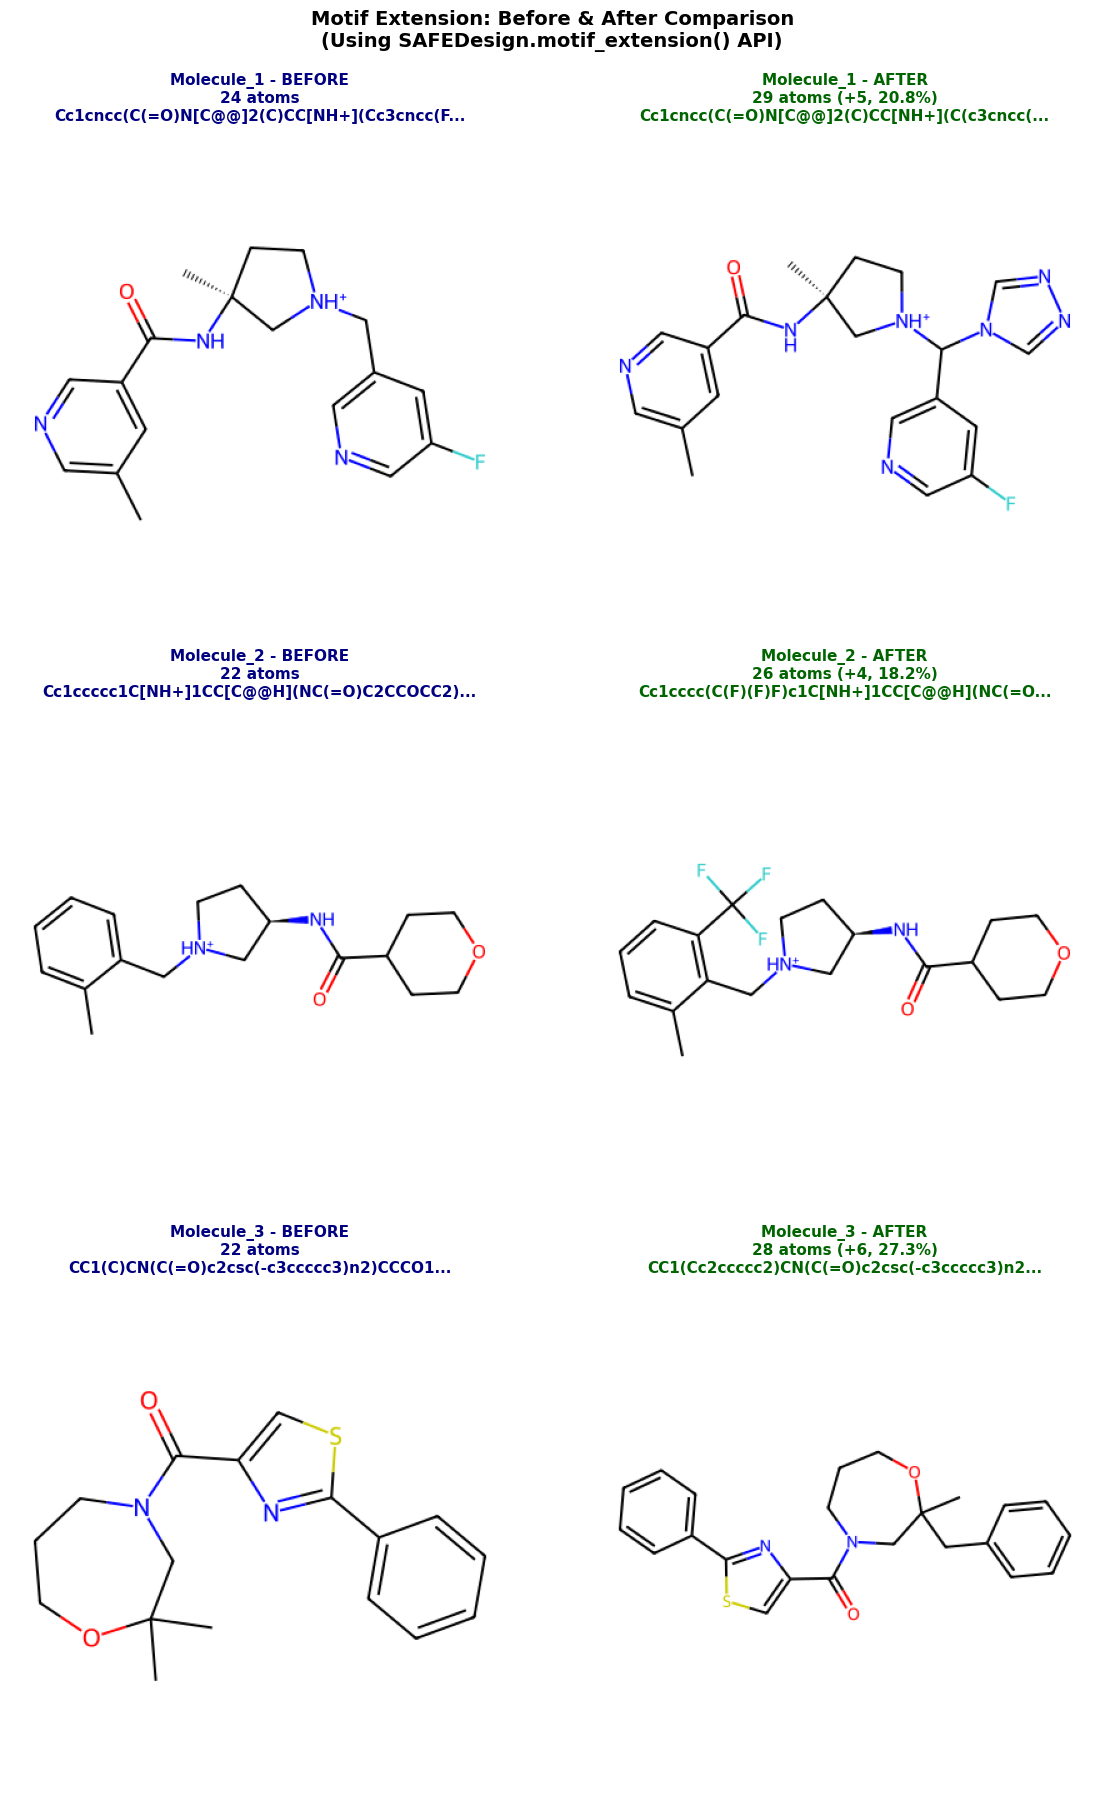

In [ ]:
# Create comprehensive before/after visualizations for motif extension
import matplotlib.pyplot as plt
from rdkit.Chem import Draw

def visualize_motif_extension(test_molecules, linker, n_samples=3):
    """
    Create before/after visualization grid for motif extension.
    Shows original molecules and their extensions.
    """
    
    # Prepare data for visualization
    molecules_data = []
    
    for mol_data in test_molecules[:n_samples]:
        motif_smiles = mol_data['smiles']
        original_mol = dm.to_mol(motif_smiles)
        
        if original_mol is None:
            continue
        
        # Perform motif extension
        extended_smiles = linker.add_with_motif_extension(motif_smiles, n_candidates=5)
        extended_mol = dm.to_mol(extended_smiles) if extended_smiles else None
        
        molecules_data.append({
            'name': mol_data['name'],
            'original_smiles': motif_smiles,
            'original_mol': original_mol,
            'extended_smiles': extended_smiles,
            'extended_mol': extended_mol,
            'growth': extended_mol.GetNumAtoms() - original_mol.GetNumAtoms() if extended_mol else 0
        })
    
    # Create visualization grid: before/after for each molecule
    n_rows = len(molecules_data)
    fig, axes = plt.subplots(n_rows, 2, figsize=(12, 6*n_rows))
    
    if n_rows == 1:
        axes = axes.reshape(1, -1)
    
    for row, mol_data in enumerate(molecules_data):
        # BEFORE: Original molecule
        orig_mol = mol_data['original_mol']
        if orig_mol:
            AllChem.Compute2DCoords(orig_mol)
            img = Draw.MolToImage(orig_mol, size=(400, 400))
            axes[row, 0].imshow(img)
        
        orig_atoms = orig_mol.GetNumAtoms() if orig_mol else 0
        axes[row, 0].set_title(
            f"{mol_data['name']} - BEFORE\n{orig_atoms} atoms\n{mol_data['original_smiles'][:40]}...",
            fontsize=11, fontweight='bold', color='navy', pad=10
        )
        axes[row, 0].axis('off')
        
        # AFTER: Extended molecule
        ext_mol = mol_data['extended_mol']
        if ext_mol:
            AllChem.Compute2DCoords(ext_mol)
            img = Draw.MolToImage(ext_mol, size=(400, 400))
            axes[row, 1].imshow(img)
        
        ext_atoms = ext_mol.GetNumAtoms() if ext_mol else 0
        growth = mol_data['growth']
        growth_pct = 100 * growth / orig_atoms if orig_atoms > 0 else 0
        
        axes[row, 1].set_title(
            f"{mol_data['name']} - AFTER\n{ext_atoms} atoms (+{growth}, {growth_pct:.1f}%)\n{mol_data['extended_smiles'][:40]}...",
            fontsize=11, fontweight='bold', color='darkgreen', pad=10
        )
        axes[row, 1].axis('off')
    
    fig.suptitle('Motif Extension: Before & After Comparison\n(Using SAFEDesign.motif_extension() API)',
                 fontsize=14, fontweight='bold', y=0.995)
    plt.tight_layout()
    plt.show()

# Generate visualizations
print("\n" + "="*80)
print("MOTIF EXTENSION VISUALIZATION")
print("="*80 + "\n")
visualize_motif_extension(test_molecules, linker, n_samples=3)




ALL MUTATION TYPES VISUALIZATION



The following generation flags are not valid and may be ignored: ['early_stopping']. Set `TRANSFORMERS_VERBOSITY=info` for more details.
[16:05:02] WARNING: not removing hydrogen atom without neighbors
[16:05:02] WARNING: not removing hydrogen atom without neighbors
The following generation flags are not valid and may be ignored: ['early_stopping']. Set `TRANSFORMERS_VERBOSITY=info` for more details.
[16:05:04] WARNING: not removing hydrogen atom without neighbors
[16:05:04] WARNING: not removing hydrogen atom without neighbors
[16:05:04] WARNING: not removing hydrogen atom without neighbors
The following generation flags are not valid and may be ignored: ['early_stopping']. Set `TRANSFORMERS_VERBOSITY=info` for more details.
[16:05:05] WARNING: not removing hydrogen atom without neighbors
[16:05:05] WARNING: not removing hydrogen atom without neighbors
[16:05:05] WARNING: not removing hydrogen atom without neighbors
The following generation flags are not valid and may be ignored: ['ea

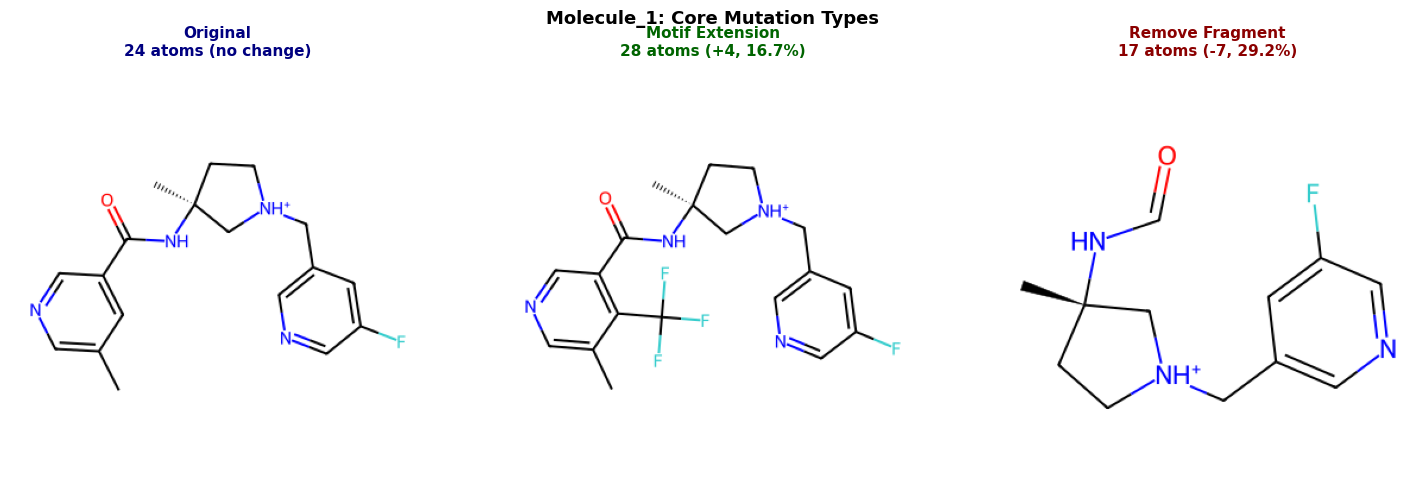

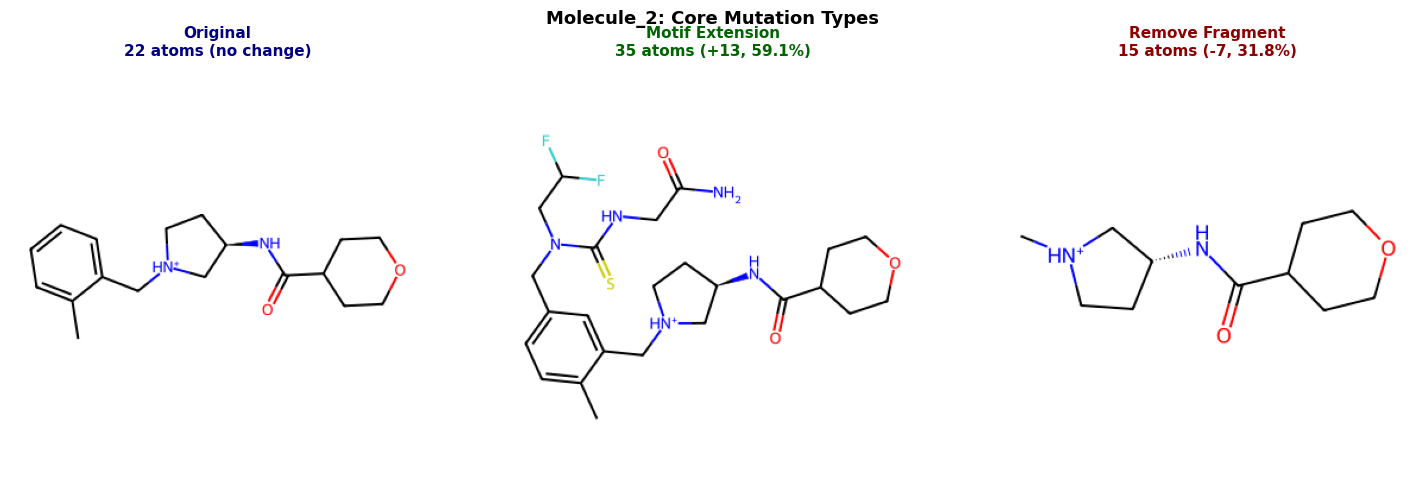

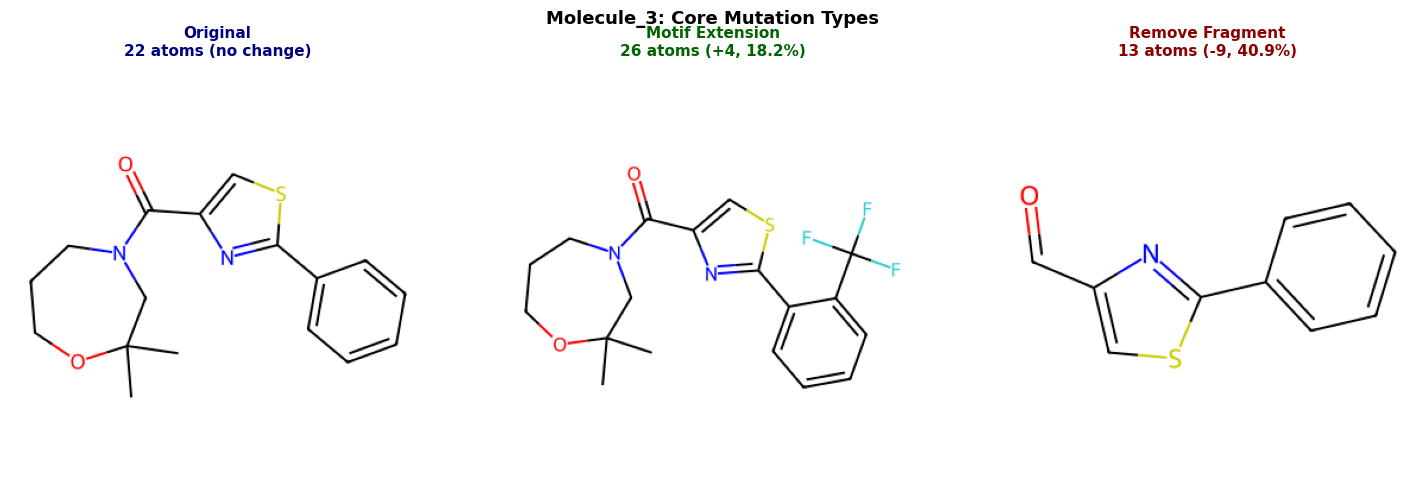

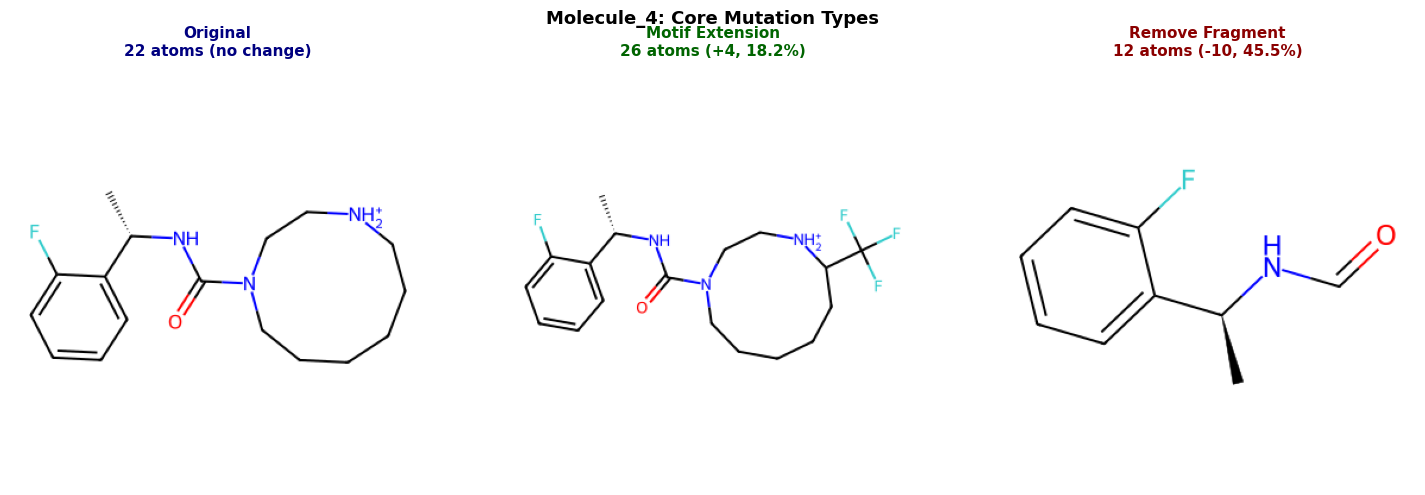

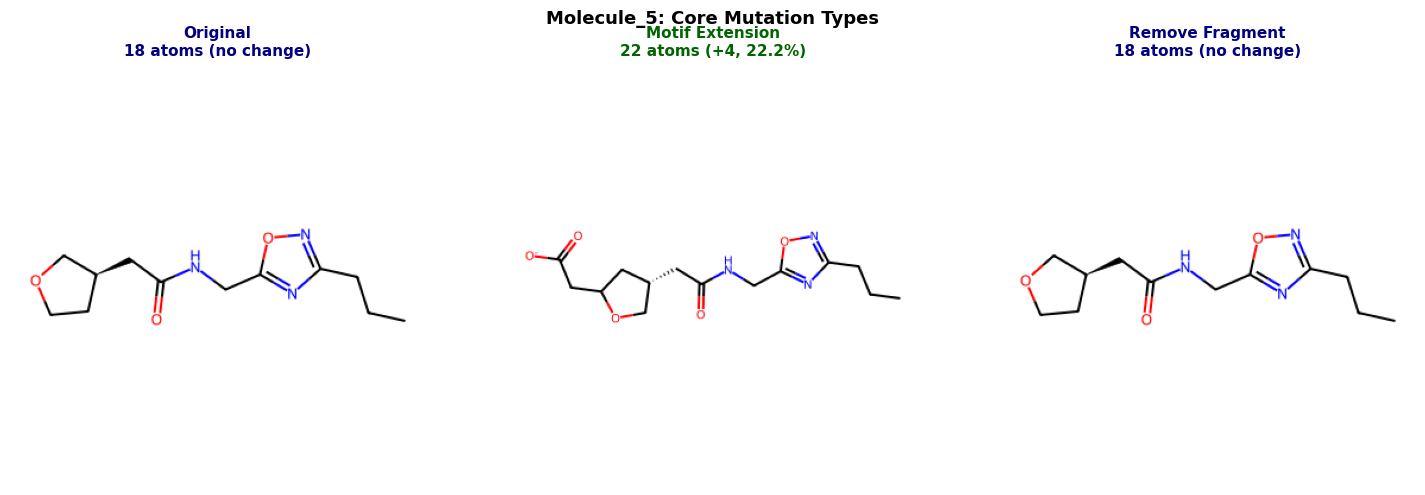

In [118]:

# Additional visualization: Core mutation types comparison
def visualize_all_mutations(test_molecules, linker, fragment_pool, n_samples=5):
    """
    Create visualization showing core mutation types: 
    original, motif extension, remove fragment, mutate attachment points.
    """
    
    molecules_to_show = []
    
    for mol_data in test_molecules[:n_samples]:
        motif_smiles = mol_data['smiles']
        original_mol = dm.to_mol(motif_smiles)
        
        if original_mol is None:
            continue
        
        AllChem.Compute2DCoords(original_mol)
        
        mutations = {
            'Original': (original_mol, motif_smiles, original_mol.GetNumAtoms()),
        }
        
        # Motif Extension
        extended_smiles = linker.add_with_motif_extension(motif_smiles, n_candidates=5)
        if extended_smiles:
            ext_mol = dm.to_mol(extended_smiles)
            if ext_mol:
                AllChem.Compute2DCoords(ext_mol)
                mutations['Motif Extension'] = (ext_mol, extended_smiles, ext_mol.GetNumAtoms())
        
        # Remove Fragment (for multi-fragment molecules)
        safe_orig = linker.encode_smiles_to_safe(motif_smiles)
        if safe_orig:
            safe_frags = linker.split_safe_fragments(safe_orig)
            if len(safe_frags) > 1:
                safe_removed = linker.remove_fragment(safe_orig)
                removed_smiles = linker.decode_safe_to_smiles(safe_removed)
                if removed_smiles:
                    removed_mol = dm.to_mol(removed_smiles)
                    if removed_mol:
                        AllChem.Compute2DCoords(removed_mol)
                        mutations['Remove Fragment'] = (removed_mol, removed_smiles, removed_mol.GetNumAtoms())
        
        
        molecules_to_show.append({
            'name': mol_data['name'],
            'mutations': mutations,
            'orig_atoms': original_mol.GetNumAtoms()
        })
    
    # Create visualization grid
    for mol_idx, mol_data in enumerate(molecules_to_show):
        mutations = mol_data['mutations']
        orig_atoms = mol_data['orig_atoms']
        
        fig, axes = plt.subplots(1, len(mutations), figsize=(5*len(mutations), 5))
        
        if len(mutations) == 1:
            axes = [axes]
        
        for ax_idx, (mut_name, (mol, smiles, atom_count)) in enumerate(mutations.items()):
            if mol:
                img = Draw.MolToImage(mol, size=(350, 350))
                axes[ax_idx].imshow(img)
            
            growth = atom_count - orig_atoms
            if growth == 0:
                color = 'navy'
                title_text = f"{mut_name}\n{atom_count} atoms (no change)"
            elif growth > 0:
                color = 'darkgreen'
                growth_pct = 100 * growth / orig_atoms
                title_text = f"{mut_name}\n{atom_count} atoms (+{growth}, {growth_pct:.1f}%)"
            else:
                color = 'darkred'
                loss_pct = 100 * abs(growth) / orig_atoms
                title_text = f"{mut_name}\n{atom_count} atoms ({growth}, {loss_pct:.1f}%)"
            
            axes[ax_idx].set_title(title_text, fontsize=11, fontweight='bold', color=color, pad=10)
            axes[ax_idx].axis('off')
        
        fig.suptitle(f'{mol_data["name"]}: Core Mutation Types', fontsize=13, fontweight='bold')
        plt.tight_layout()
        plt.show()

# Generate all mutations visualization
print("\n" + "="*80)
print("ALL MUTATION TYPES VISUALIZATION")
print("="*80 + "\n")
visualize_all_mutations(test_molecules, linker, fragment_pool, n_samples=5)
